In [1]:
# Packages
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


#pr méthodes supervisées
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from xgboost import XGBClassifier
import gc  # garbage collector pour libérer la RAM
import plotly.io as pio
pio.renderers.default = 'browser'
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

In [2]:
# Chargement des données et premier nettoyage

#chemin_fichier = r'C:\Users\nolhan\Drive\OneDrive\Documents\Ecole\E4 Machine learning\dataset_lymphocytes_annotes.h5ad'
chemin_fichier = r'dataset_lymphocytes_annotes.h5ad'


print("Chargement des données...")
adata = sc.read_h5ad(chemin_fichier)

# taille avant le filtrage
print("Dimensions avant filtrage :", adata.shape)

# garde uniquement les gènes qui sont exprimés dans au moins 1 cellule
sc.pp.filter_genes(adata, min_cells=100)

# Affiche la taille après le filtrage
print("Dimensions après filtrage :", adata.shape)

Chargement des données...
Dimensions avant filtrage : (54137, 33538)
Dimensions après filtrage : (54137, 12718)


In [3]:
# Données manquantes
print("\n Donnée manquante et sparsité")
# On vérifie s'il y a des "trous" (NaN) dans nos étiquettes et informations

valeurs_nulles = adata.obs.isnull().sum()
print("Valeurs nulles dans les cellules :")
print(valeurs_nulles[valeurs_nulles > 0]) 

if valeurs_nulles.sum() == 0:
    print("-> Aucune donnée manquante dans les métadonnées.")

# Une cellule n'exprime pas tous ses gènes en même temps (beaucoup de zéros)
sparsite = 1.0 - (adata.X.nnz / (adata.shape[0] * adata.shape[1]))
print(f"-> Sparsité de la matrice génétique : {sparsite * 100:.2f}% de zéros.")


 Donnée manquante et sparsité
Valeurs nulles dans les cellules :
Series([], dtype: int64)
-> Aucune donnée manquante dans les métadonnées.
-> Sparsité de la matrice génétique : 90.00% de zéros.



 Déséquilibre des classes
cell_type
Tem/Trm cytotoxic T cells                17537
Tcm/Naive cytotoxic T cells              15619
Tem/Temra cytotoxic T cells              13422
Tcm/Naive helper T cells                  3522
MAIT cells                                1041
Memory B cells                             872
NK cells                                   616
Tem/Effector helper T cells                365
CD16+ NK cells                             204
Trm cytotoxic T cells                      198
CRTAM+ gamma-delta T cells                 133
CD8a/a                                     114
Alveolar macrophages                        73
NKT cells                                   65
Regulatory T cells                          57
ILC3                                        50
Double-positive thymocytes                  26
Naive B cells                               24
CD16- NK cells                              24
Classical monocytes                         23
Treg(diff)             

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\338186916.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comptage_classes.index, y=comptage_classes.values, palette='viridis')


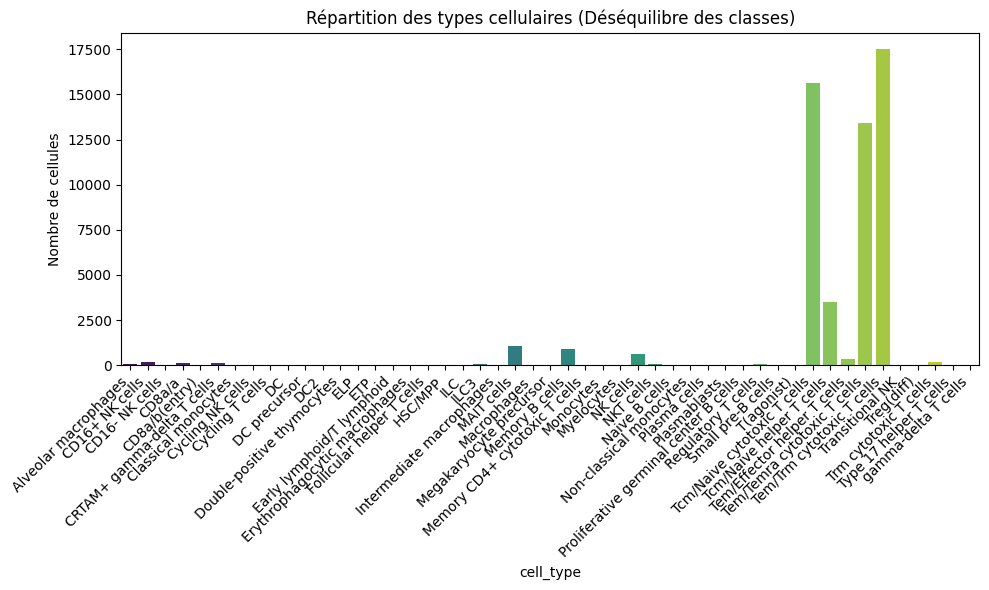


--- SÉLECTION DES TYPES CELLULAIRES ---
Nouvelles dimensions après filtrage : (46578, 12718)

Vérification des classes restantes :
cell_type
Tem/Trm cytotoxic T cells      17537
Tcm/Naive cytotoxic T cells    15619
Tem/Temra cytotoxic T cells    13422
Name: count, dtype: int64


In [4]:
# Observations des classes
print("\n Déséquilibre des classes")
# Compter le nombre de cellules par type

# nb de cellules par type
comptage_classes = adata.obs['cell_type'].value_counts()

# exclu les catégories à 0
comptage_classes = comptage_classes[comptage_classes > 0]

print(comptage_classes)

# graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=comptage_classes.index, y=comptage_classes.values, palette='viridis')
plt.title("Répartition des types cellulaires (Déséquilibre des classes)")
plt.ylabel("Nombre de cellules")
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


# Sélection classes 

print("\n--- SÉLECTION DES TYPES CELLULAIRES ---")

classes_a_garder = [
    'Tem/Trm cytotoxic T cells',
    'Tcm/Naive cytotoxic T cells',
    'Tem/Temra cytotoxic T cells'
]

# filtre 
adata = adata[adata.obs['cell_type'].isin(classes_a_garder)].copy()

# Nettoyage des catégories
if adata.obs['cell_type'].dtype.name == 'category':
    adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()

print("Nouvelles dimensions après filtrage :", adata.shape)
print("\nVérification des classes restantes :")
print(adata.obs['cell_type'].value_counts())


 Corrélation


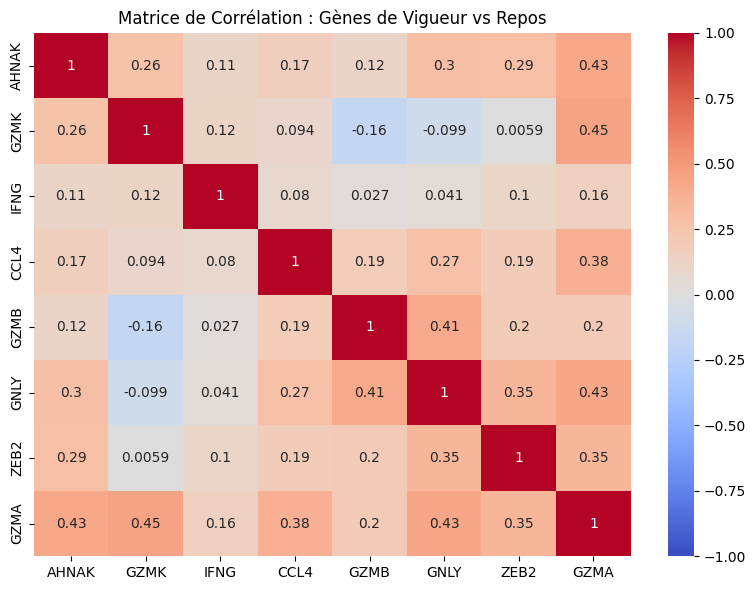

In [12]:
print("\n Corrélation")

genes_cibles = [
    'AHNAK', 
    'HNRNPLL',  
    'GZMK',  
    'GZMM',  
    'IFNG',  
    'CCL4',
    'CCL5',
    'GZMB',
    'GNLY',
    'NKG7',
    'ZEB2',
    'GZMA',         
]

# On vérifie quels gènes sont bien présents dans notre matrice
genes_presents = [gene for gene in genes_cibles if gene in adata.var_names]

df_genes = sc.get.obs_df(adata, keys=genes_presents)

# corrélation de Pearson
matrice_correlation = df_genes.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matrice_correlation, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title("Matrice de Corrélation : Gènes de Vigueur vs Repos")
plt.tight_layout()
#plt.savefig('correlation_genes.png')
plt.show()


 Normalisation 


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)



 PCA 


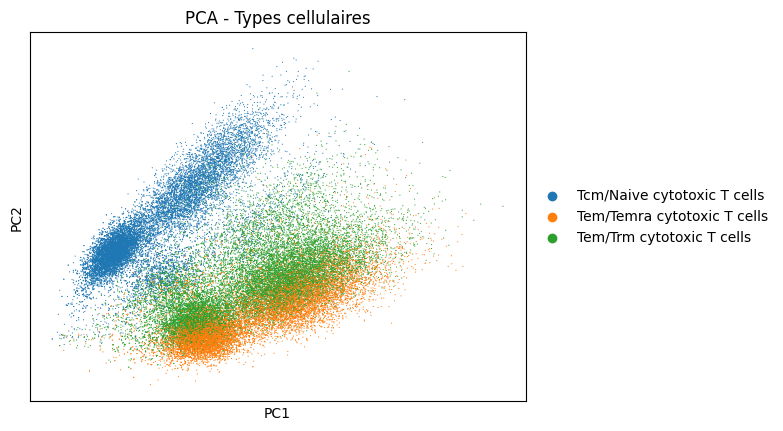


 UMAP 


C:\Users\Emica\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


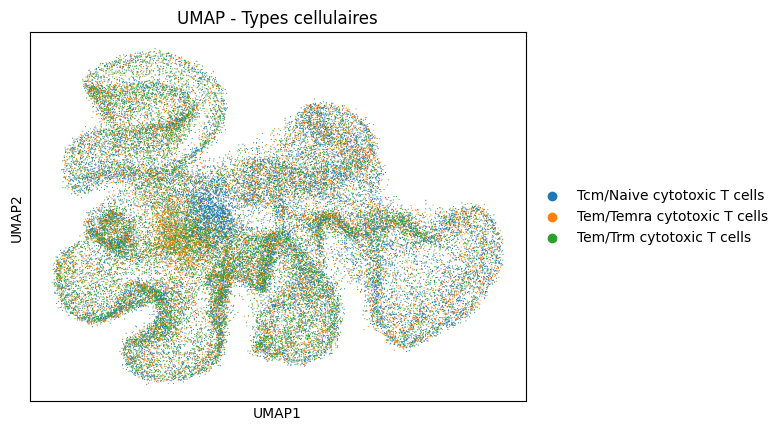


 T-SNE 


C:\Users\Emica\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  return fn(*args_all, **kw)


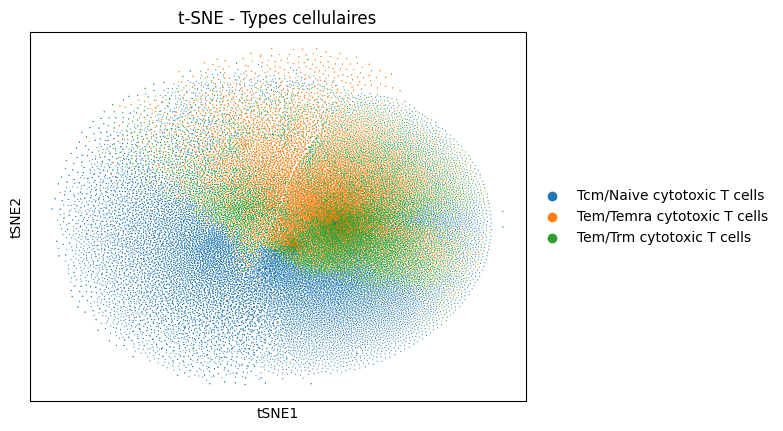

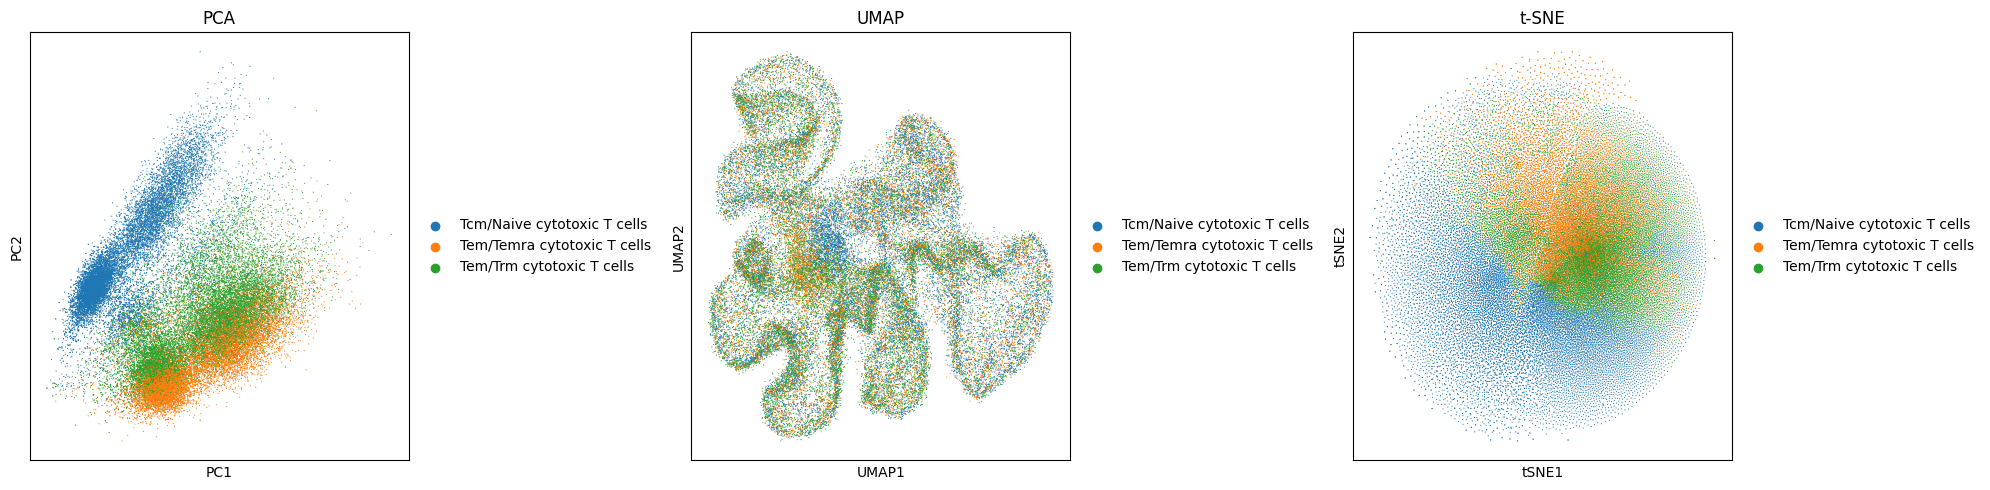

Méthode  Silhouette    ARI    NMI
    PCA      0.0993 0.4139 0.4378
   UMAP     -0.0161 0.0071 0.0056
  t-SNE      0.0693 0.1911 0.2079


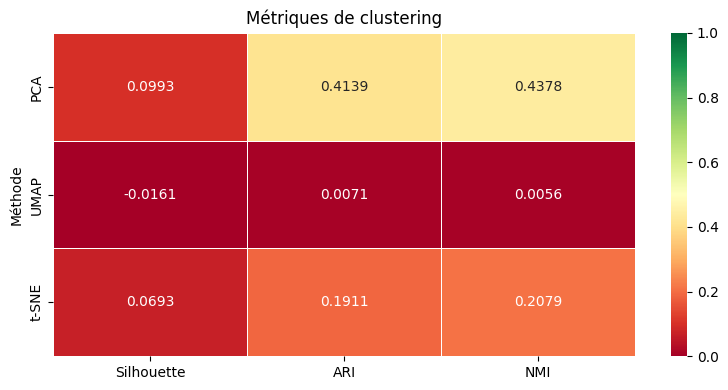

In [6]:
print("\n Normalisation ")
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)

# Encodage des vraies étiquettes
le = LabelEncoder()
y_true = le.fit_transform(adata.obs['cell_type'])
resultats_clustering = []

# PCA
print("\n PCA ")
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca(adata, color=['cell_type'], title='PCA - Types cellulaires')

resultats_clustering.append({
    'Méthode'   : 'PCA',
    'Silhouette': round(silhouette_score(
        adata.obsm['X_pca'], y_true, sample_size=5000, random_state=42), 4),
})

# UMAP
print("\n UMAP ")
sc.pp.neighbors(adata, use_rep='X', n_neighbors=10)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type'], title='UMAP - Types cellulaires')

resultats_clustering.append({
    'Méthode'   : 'UMAP',
    'Silhouette': round(silhouette_score(
        adata.obsm['X_umap'], y_true, sample_size=5000, random_state=42), 4),
})

# t-SNE
print("\n T-SNE ")
sc.tl.tsne(adata, use_rep='X', perplexity=30, n_jobs=-1)
sc.pl.tsne(adata, color=['cell_type'], title='t-SNE - Types cellulaires')

resultats_clustering.append({
    'Méthode'   : 't-SNE',
    'Silhouette': round(silhouette_score(
        adata.obsm['X_tsne'], y_true, sample_size=5000, random_state=42), 4),
})

# Comparaison visuelle
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sc.pl.pca(adata,  color='cell_type', title='PCA',   ax=axes[0], show=False)
sc.pl.umap(adata, color='cell_type', title='UMAP',  ax=axes[1], show=False)
sc.pl.tsne(adata, color='cell_type', title='t-SNE', ax=axes[2], show=False)
plt.tight_layout()
plt.savefig('pca_vs_umap_vs_tsne.png', dpi=150)
plt.show()

def metriques_clustering(X, y_true, nom, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    y_kmeans = kmeans.fit_predict(X)
    return {
        'Méthode'   : nom,
        'Silhouette': round(silhouette_score(X, y_true, sample_size=5000, random_state=42), 4),
        'ARI'       : round(adjusted_rand_score(y_true, y_kmeans), 4),
        'NMI'       : round(normalized_mutual_info_score(y_true, y_kmeans), 4),
    }

resultats_clustering = []
resultats_clustering.append(metriques_clustering(adata.obsm['X_pca'],  y_true, 'PCA'))
resultats_clustering.append(metriques_clustering(adata.obsm['X_umap'], y_true, 'UMAP'))
resultats_clustering.append(metriques_clustering(adata.obsm['X_tsne'], y_true, 't-SNE'))

df_clustering = pd.DataFrame(resultats_clustering)
print(df_clustering.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.heatmap(df_clustering.set_index('Méthode'), annot=True, fmt='.4f',
            cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5)
plt.title('Métriques de clustering')
plt.tight_layout()
plt.savefig('metriques_clustering.png', dpi=150)
plt.show()

In [7]:
#Comparaison des CP (inutile si on utilise le 3D)
"""
# PC1 vs PC2 (défaut)
sc.pl.pca(adata, color='cell_type', components='1,2', title='PCA - PC1 vs PC2')

# PC1 vs PC3
sc.pl.pca(adata, color='cell_type', components='1,3', title='PCA - PC1 vs PC3')

# PC2 vs PC3
sc.pl.pca(adata, color='cell_type', components='2,3', title='PCA - PC2 vs PC3')
"""

"\n# PC1 vs PC2 (défaut)\nsc.pl.pca(adata, color='cell_type', components='1,2', title='PCA - PC1 vs PC2')\n\n# PC1 vs PC3\nsc.pl.pca(adata, color='cell_type', components='1,3', title='PCA - PC1 vs PC3')\n\n# PC2 vs PC3\nsc.pl.pca(adata, color='cell_type', components='2,3', title='PCA - PC2 vs PC3')\n"

In [8]:
# UMAP 3D basé sur les PCs de la PCA

print("\n UMAP 3D avec les PCs de la PCA ")

sc.pp.neighbors(adata, use_rep='X_pca', n_neighbors=10, n_pcs=40)
sc.tl.umap(adata, n_components=3)

df_umap3d = pd.DataFrame({
    'UMAP1'     : adata.obsm['X_umap'][:, 0],
    'UMAP2'     : adata.obsm['X_umap'][:, 1],
    'UMAP3'     : adata.obsm['X_umap'][:, 2],
    'cell_type' : adata.obs['cell_type'].values
})

# Visualisation 
fig = px.scatter_3d(
    df_umap3d,
    x='UMAP1', y='UMAP2', z='UMAP3',
    color='cell_type',
    opacity=0.6,
    title='UMAP 3D (basé sur les PCs de la PCA)'
)
fig.update_traces(marker=dict(size=2))
fig.write_html('umap_3d_pca.html')
fig.show()


 UMAP 3D avec les PCs de la PCA 



--- 6. GÈNES COMPOSANT LES PCA ---


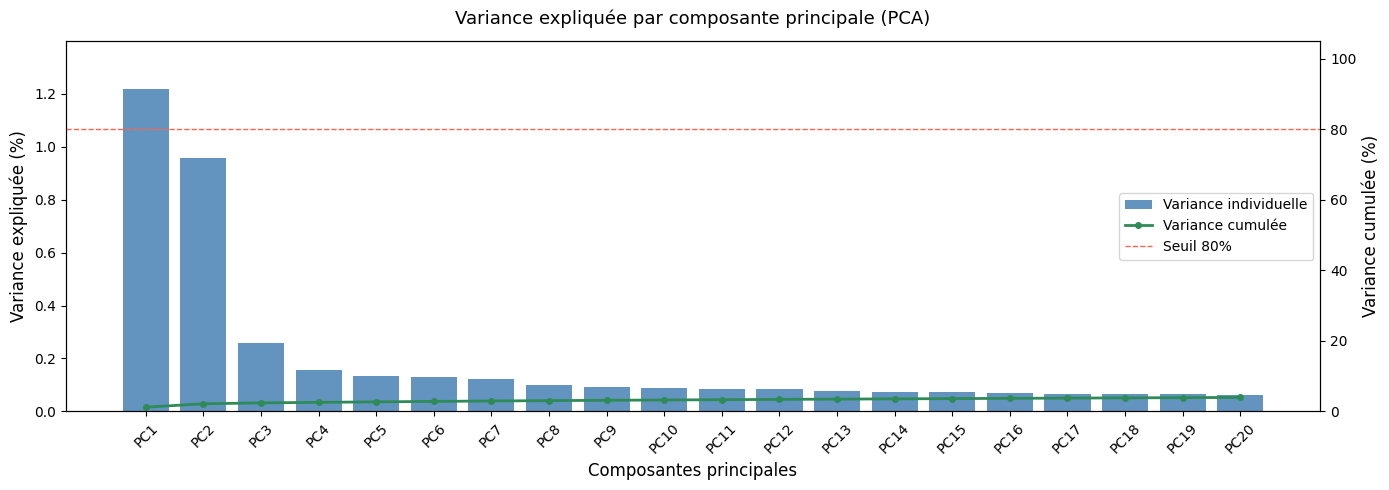

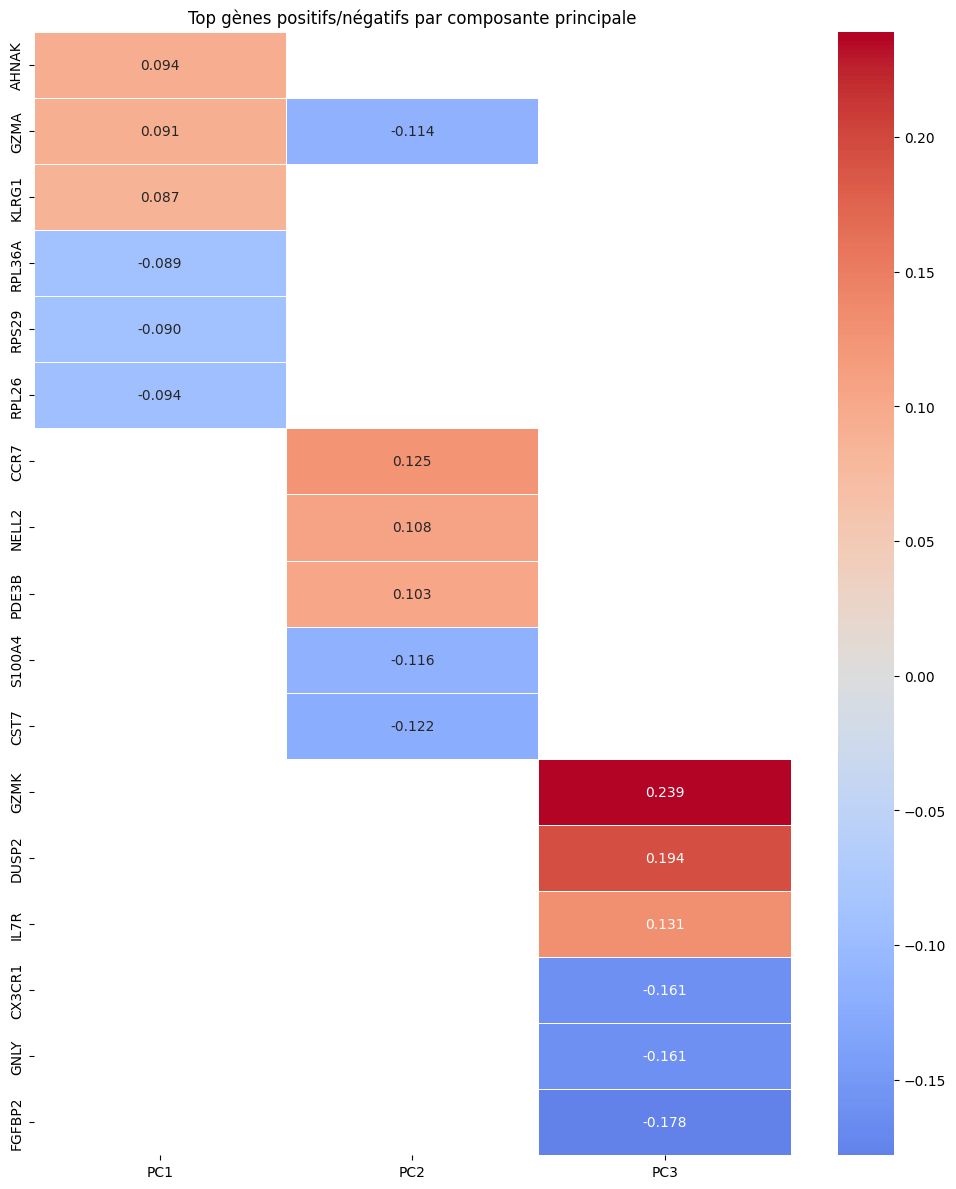

In [ ]:
print("\n Gène dans les PC")

# ratio de variance expliquée (valeurs entre 0 et 1)
variance_ratio = adata.uns['pca']['variance_ratio']

# Nombre de composantes à afficher
n_pcs = 20

# calcul de la variance cumulée
variance_cumulee = np.cumsum(variance_ratio[:n_pcs]) * 100
variance_individuelle = variance_ratio[:n_pcs] * 100
labels = [f'PC{i+1}' for i in range(n_pcs)]


#  diagramme 
fig, ax1 = plt.subplots(figsize=(14, 5))

# variance individuelle
ax1.bar(labels, variance_individuelle, color='steelblue', alpha=0.85, label='Variance individuelle')
ax1.set_ylabel('Variance expliquée (%)', fontsize=12)
ax1.set_xlabel('Composantes principales', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylim(0, variance_individuelle.max() * 1.15)

# variance cumulée (axe secondaire)
ax2 = ax1.twinx()
ax2.plot(labels, variance_cumulee, color='seagreen', marker='o', markersize=4,
         linewidth=2, label='Variance cumulée')
ax2.set_ylabel('Variance cumulée (%)', fontsize=12)
ax2.set_ylim(0, 105)
ax2.axhline(y=80, color='tomato', linestyle='--', linewidth=1, label='Seuil 80%')

# légende combinée
lignes1, labels1 = ax1.get_legend_handles_labels()
lignes2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lignes1 + lignes2, labels1 + labels2, loc='center right', fontsize=10)

plt.title('Variance expliquée par composante principale (PCA)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150)
plt.show()


# loadings = poids de chaque gène dans chaque PC
# Stockés dans adata.varm['PCs'] : shape (n_genes, n_pcs)
loadings = pd.DataFrame(
    adata.varm['PCs'],
    index=adata.var_names,       # noms des gènes
    columns=[f'PC{i+1}' for i in range(adata.varm['PCs'].shape[1])]
)

# Heatmap top gènes sur PC1 et PC2 
def top_genes_pc(loadings, pc, n=3):
    #Retourne les n gènes avec les loadings les plus extrêmes (+ et -)
    sorted_pc = loadings[pc].sort_values(ascending=False)
    return pd.concat([sorted_pc.head(n), sorted_pc.tail(n)])

pcs_a_visualiser = ['PC1', 'PC2', 'PC3']
top_genes_all = pd.concat([top_genes_pc(loadings, pc) for pc in pcs_a_visualiser], axis=1)
top_genes_all.columns = pcs_a_visualiser


plt.figure(figsize=(10, 12))
sns.heatmap(
    top_genes_all,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5
)
plt.title("Top gènes positifs/négatifs par composante principale")
plt.tight_layout()
plt.show()



  Arbre de décision - PCA
Fitting 5 folds for each of 45 candidates, totalling 225 fits
Meilleurs params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
                             precision    recall  f1-score   support

Tcm/Naive cytotoxic T cells       0.94      0.94      0.94      3124
Tem/Temra cytotoxic T cells       0.87      0.89      0.88      2684
  Tem/Trm cytotoxic T cells       0.87      0.86      0.87      3508

                   accuracy                           0.89      9316
                  macro avg       0.89      0.90      0.90      9316
               weighted avg       0.89      0.89      0.89      9316



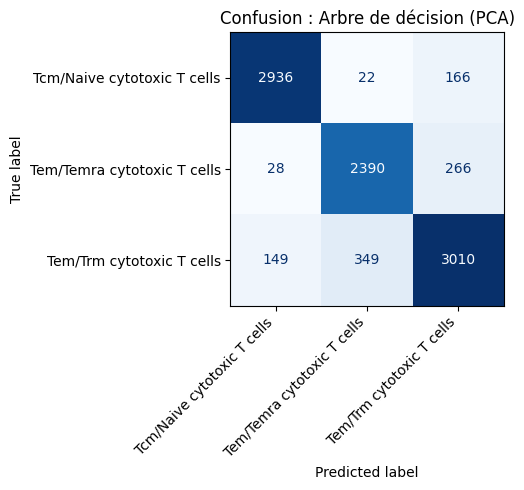

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\3344576298.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.index, y=importances.values, palette='viridis')


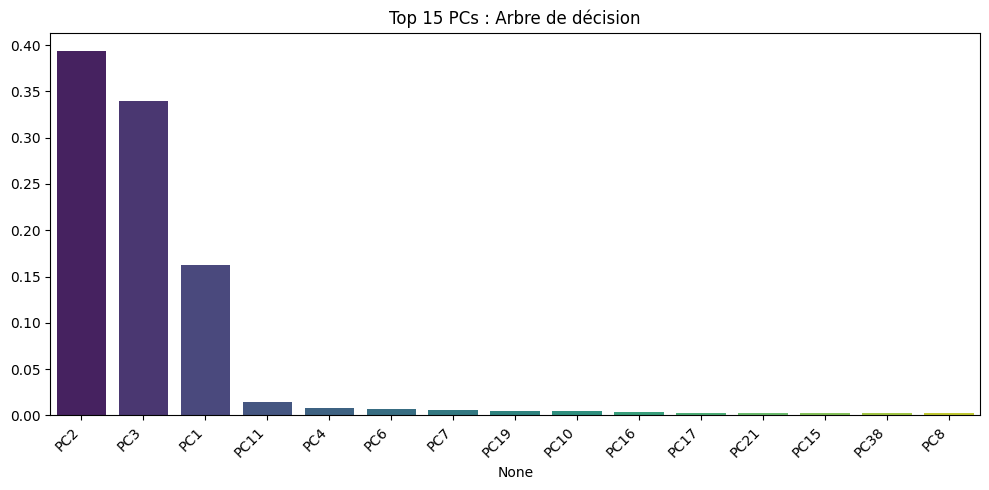


  Random Forest - PCA
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs params : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
                             precision    recall  f1-score   support

Tcm/Naive cytotoxic T cells       0.97      0.95      0.96      3124
Tem/Temra cytotoxic T cells       0.91      0.92      0.91      2684
  Tem/Trm cytotoxic T cells       0.90      0.91      0.90      3508

                   accuracy                           0.92      9316
                  macro avg       0.92      0.92      0.92      9316
               weighted avg       0.92      0.92      0.92      9316



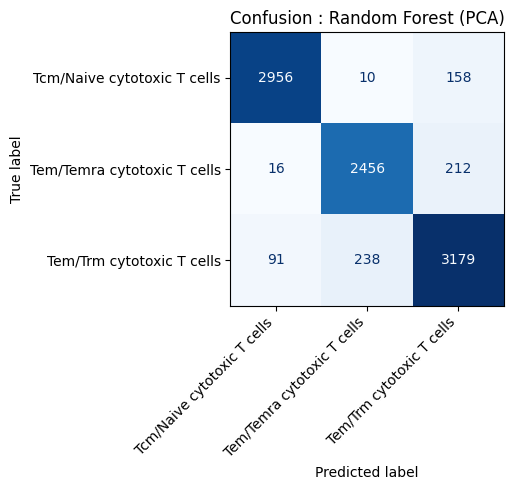

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\3344576298.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.index, y=importances.values, palette='viridis')


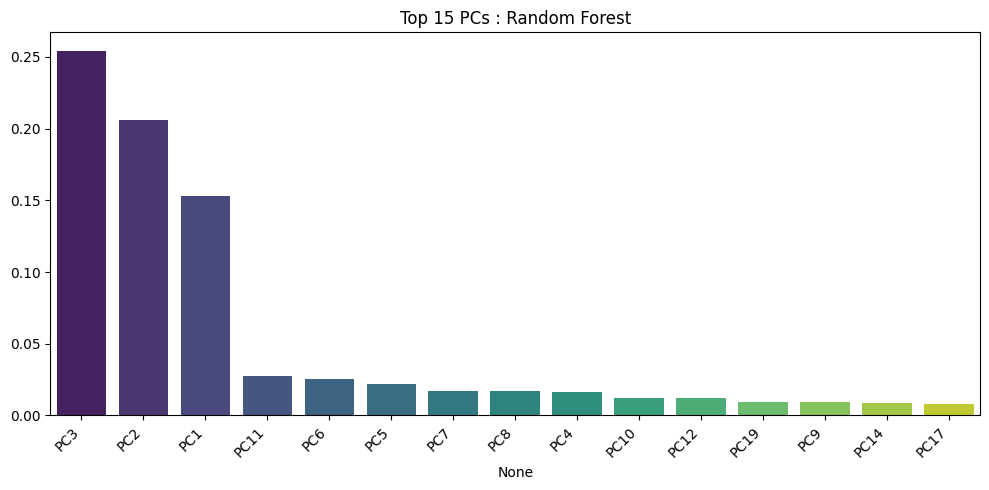


  XGBoost - PCA
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs params : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
                             precision    recall  f1-score   support

Tcm/Naive cytotoxic T cells       0.96      0.96      0.96      3124
Tem/Temra cytotoxic T cells       0.92      0.90      0.91      2684
  Tem/Trm cytotoxic T cells       0.90      0.91      0.91      3508

                   accuracy                           0.93      9316
                  macro avg       0.93      0.93      0.93      9316
               weighted avg       0.93      0.93      0.93      9316



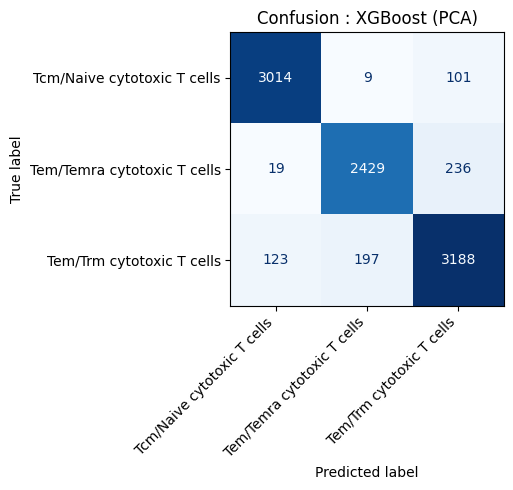

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\3344576298.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.index, y=importances.values, palette='viridis')


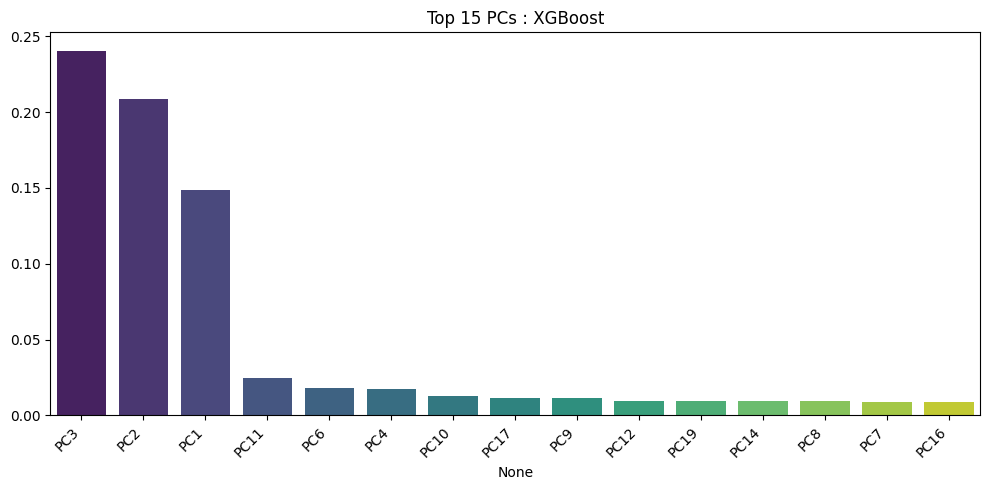


--- Récapitulatif modèles avec PCs ---
           Modèle Features  Accuracy  F1-macro  Précision-macro  Rappel-macro  F1-Naive  F1-Trm  F1-Temra
          XGBoost      PCA    0.9265    0.9266           0.9271        0.9262    0.9599  0.9133    0.9066
    Random Forest      PCA    0.9222    0.9227           0.9230        0.9225    0.9556  0.9117    0.9009
Arbre de décision      PCA    0.8948    0.8952           0.8944        0.8961    0.9415  0.8779    0.8662

--- Meilleurs paramètres pour chaque modèle ---
Arbre de décision : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Random Forest : {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
XGBoost : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [ ]:
# Modèles supervisés sur les PCs de la PCA

# Encodage des labels
le = LabelEncoder()
y = le.fit_transform(adata.obs['cell_type'])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Features PCA
X = adata.obsm['X_pca']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tableau récapitulatif et meilleurs params
resultats = []
meilleurs_params = {}

# Définition des modèles et grilles
modeles = {
    'Arbre de décision': (
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        {
            'max_depth'         : [3, 5, 7, 10, None],
            'min_samples_split' : [2, 5, 10],
            'min_samples_leaf'  : [1, 2, 5]
        }
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        {
            'n_estimators'    : [100, 200],
            'max_depth'       : [5, 10, None],
            'min_samples_leaf': [1, 2, 5]
        }
    ),
    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='mlogloss'),
        {
            'n_estimators' : [100, 200],
            'max_depth'    : [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3]
        }
    )
}

resultats_complets = []

for nom_modele, (modele, param_grid) in modeles.items():
    print(f"\n{'='*50}")
    print(f"  {nom_modele} - PCA")
    print(f"{'='*50}")

    grid = GridSearchCV(
        modele, param_grid,
        scoring='f1_macro',
        cv=cv, n_jobs=-1, verbose=1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    meilleurs_params[nom_modele] = grid.best_params_

    print(f"Meilleurs params : {grid.best_params_}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Confusion : {nom_modele} (PCA)")
    plt.tight_layout()
    plt.savefig(f'confusion_{nom_modele}_pca.png'.replace(' ', '_'), dpi=150)
    plt.show()

    # Importance des features
    importances = pd.Series(
        best_model.feature_importances_,
        index=[f'PC{i+1}' for i in range(X.shape[1])]
    ).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances.index, y=importances.values, palette='viridis')
    plt.title(f"Top 15 PCs : {nom_modele}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'importance_{nom_modele}_pca.png'.replace(' ', '_'), dpi=150)
    plt.show()

    # ← Sauvegarde des métriques dans la boucle
    f1_par_classe = f1_score(y_test, y_pred, average=None)
    resultats_complets.append({
        'Modèle'         : nom_modele,
        'Features'       : 'PCA',
        'Accuracy'       : round(accuracy_score(y_test, y_pred), 4),
        'F1-macro'       : round(f1_score(y_test, y_pred, average='macro'), 4),
        'Précision-macro': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Rappel-macro'   : round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1-Naive'       : round(f1_par_classe[0], 4),
        'F1-Trm'         : round(f1_par_classe[1], 4),
        'F1-Temra'       : round(f1_par_classe[2], 4),
    })

    del grid, best_model
    gc.collect()

# Récupilatif + meilleurs params

print("\n--- Récapitulatif modèles avec PCs ---")
df_resultats = pd.DataFrame(resultats_complets).sort_values('F1-macro', ascending=False)
print(df_resultats.to_string(index=False))

print("\n--- Meilleurs paramètres pour chaque modèle ---")
for nom, params in meilleurs_params.items():
    print(f"{nom} : {params}")


=== Arbre de décision - Gènes ===
                             precision    recall  f1-score   support

Tcm/Naive cytotoxic T cells       0.91      0.95      0.93      3124
Tem/Temra cytotoxic T cells       0.86      0.90      0.88      2684
  Tem/Trm cytotoxic T cells       0.91      0.84      0.87      3508

                   accuracy                           0.90      9316
                  macro avg       0.90      0.90      0.90      9316
               weighted avg       0.90      0.90      0.90      9316



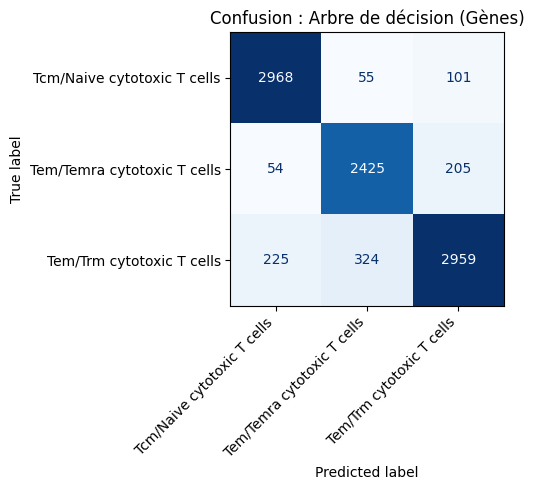

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\4018359043.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.index, y=importances.values, palette='viridis')


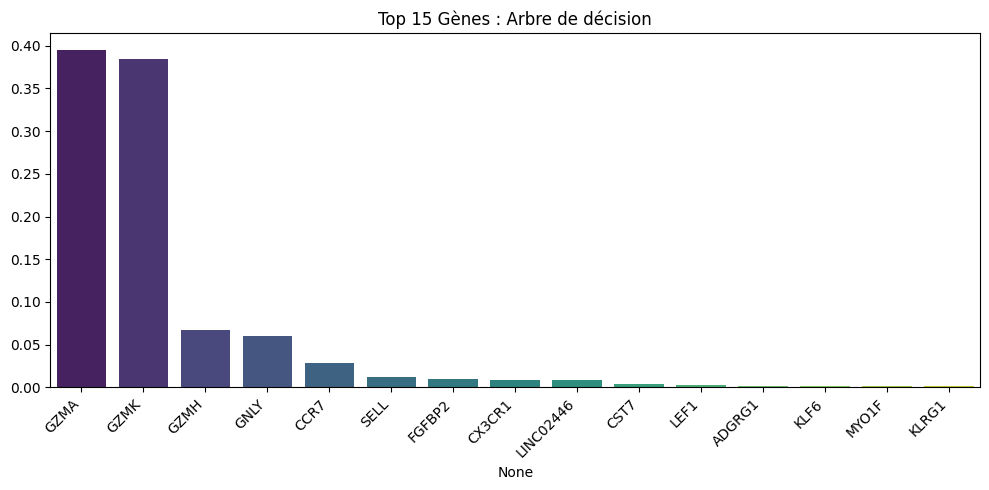

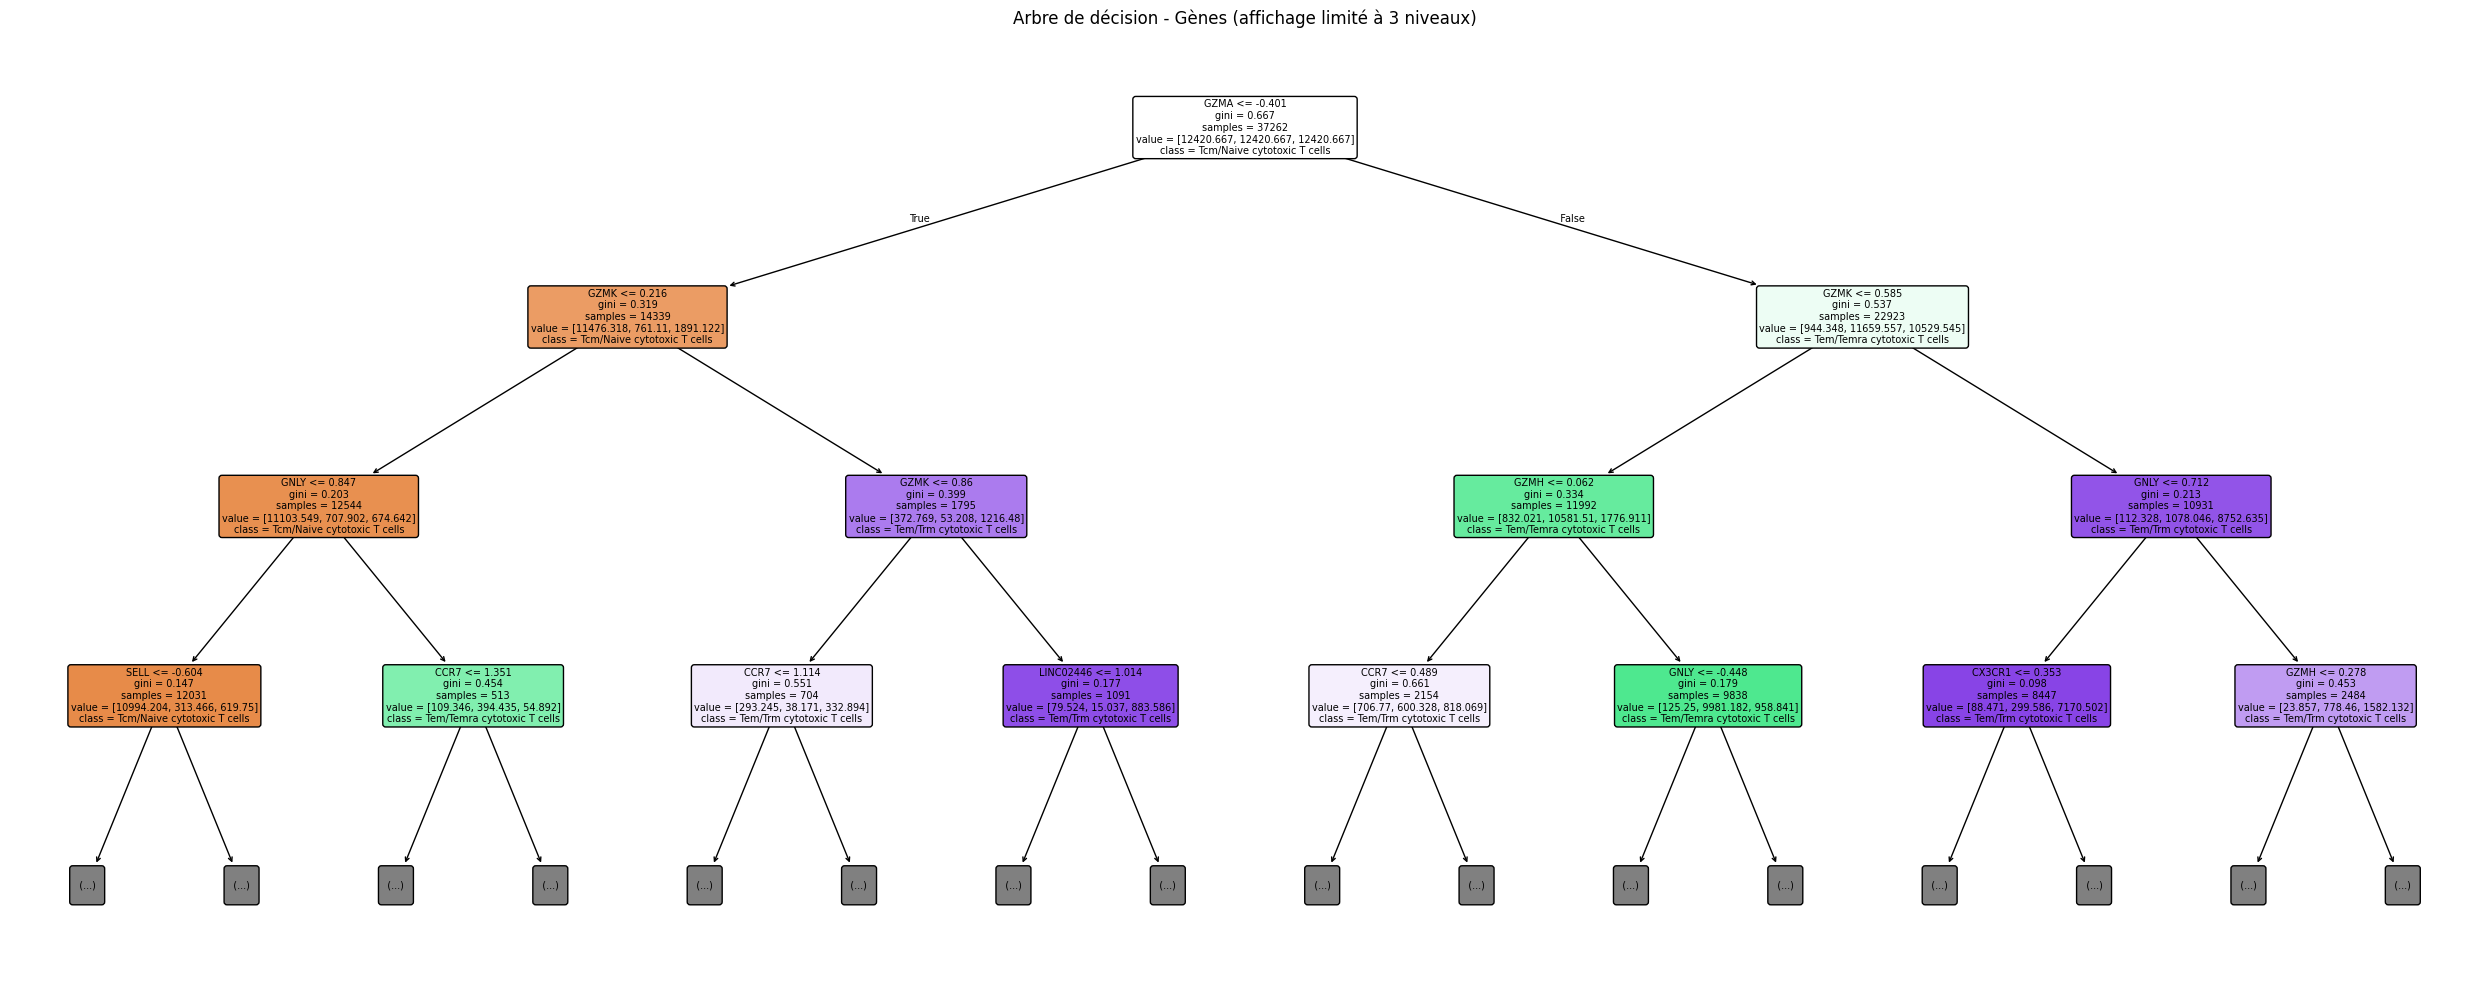


=== Random Forest - Gènes ===
                             precision    recall  f1-score   support

Tcm/Naive cytotoxic T cells       0.96      0.96      0.96      3124
Tem/Temra cytotoxic T cells       0.95      0.88      0.91      2684
  Tem/Trm cytotoxic T cells       0.89      0.94      0.91      3508

                   accuracy                           0.93      9316
                  macro avg       0.93      0.93      0.93      9316
               weighted avg       0.93      0.93      0.93      9316



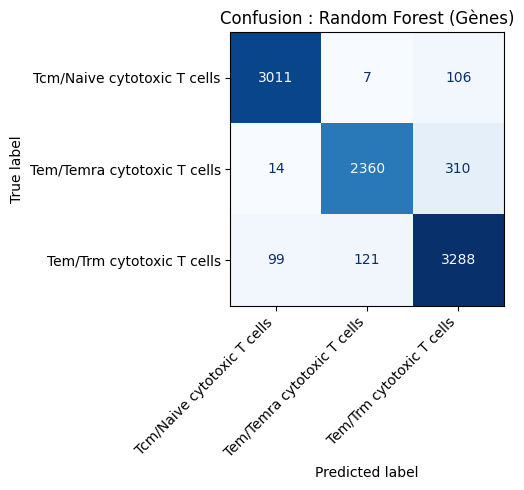

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\4018359043.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.index, y=importances.values, palette='viridis')


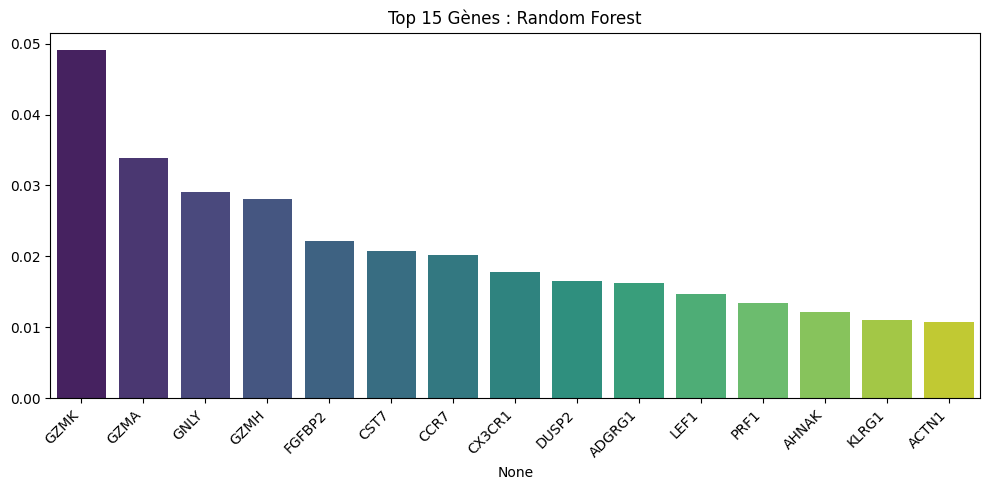


=== XGBoost - Gènes ===
                             precision    recall  f1-score   support

Tcm/Naive cytotoxic T cells       0.96      0.98      0.97      3124
Tem/Temra cytotoxic T cells       0.94      0.93      0.93      2684
  Tem/Trm cytotoxic T cells       0.94      0.92      0.93      3508

                   accuracy                           0.94      9316
                  macro avg       0.94      0.94      0.94      9316
               weighted avg       0.94      0.94      0.94      9316



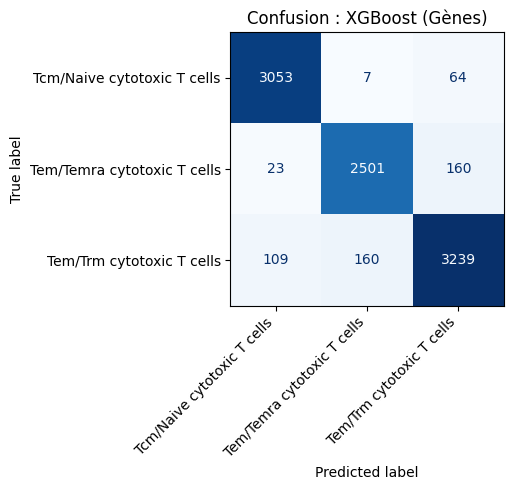

C:\Users\Emica\AppData\Local\Temp\ipykernel_13864\4018359043.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.index, y=importances.values, palette='viridis')


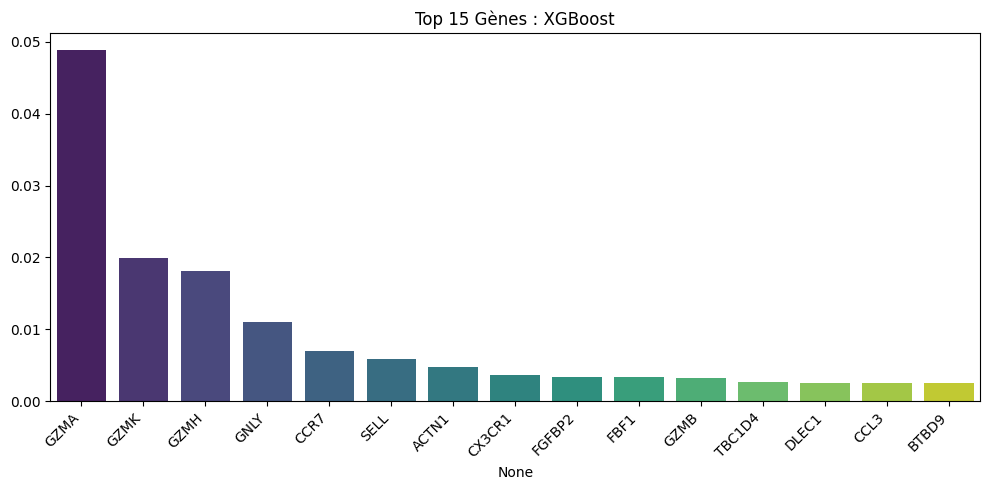


--- RÉCAPITULATIF FINAL ---
           Modèle Features  Accuracy  F1-macro  Précision-macro  Rappel-macro  F1-Naive  F1-Trm  F1-Temra
          XGBoost    Gènes    0.9439    0.9439           0.9438        0.9441    0.9678  0.9346    0.9293
    Random Forest    Gènes    0.9295    0.9294           0.9334        0.9268    0.9638  0.9126    0.9118
          XGBoost      PCA    0.9265    0.9266           0.9271        0.9262    0.9599  0.9133    0.9066
    Random Forest      PCA    0.9222    0.9227           0.9230        0.9225    0.9556  0.9117    0.9009
Arbre de décision    Gènes    0.8965    0.8964           0.8951        0.8990    0.9317  0.8837    0.8738
Arbre de décision      PCA    0.8948    0.8952           0.8944        0.8961    0.9415  0.8779    0.8662


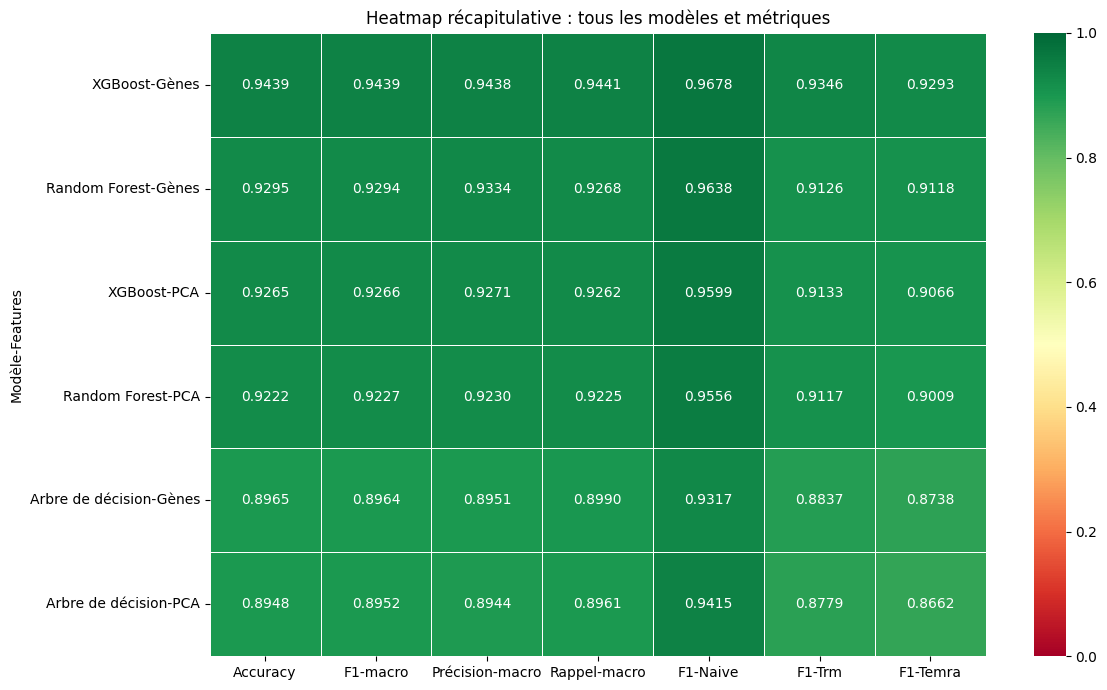

In [ ]:
# Modèles supervisés sur les gènes (avec les meilleurs params de la PCA)
meilleurs_params_arbre  = {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}
meilleurs_params_rf     = {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
meilleurs_params_xgb    = {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200}

X = adata.X if isinstance(adata.X, np.ndarray) else adata.X.toarray()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modeles_genes = {
    'Arbre de décision' : DecisionTreeClassifier(
        **meilleurs_params_arbre,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest' : RandomForestClassifier(
        **meilleurs_params_rf,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost' : XGBClassifier(
        **meilleurs_params_xgb,
        eval_metric='mlogloss',
        random_state=42
    )
}

for nom_modele, modele in modeles_genes.items():
    print(f"\n=== {nom_modele} - Gènes ===")

    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Confusion : {nom_modele} (Gènes)")
    plt.tight_layout()
    plt.savefig(f'confusion_{nom_modele}_genes.png'.replace(' ', '_'), dpi=150)
    plt.show()

    # Importance des features
    importances = pd.Series(
        modele.feature_importances_,
        index=adata.var_names.tolist()
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances.index, y=importances.values, palette='viridis')
    plt.title(f"Top 15 Gènes : {nom_modele}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'importance_{nom_modele}_genes.png'.replace(' ', '_'), dpi=150)
    plt.show()

    # Visualisation de l'arbre de décision
    if nom_modele == 'Arbre de décision':
        plt.figure(figsize=(25, 10))
        plot_tree(
            modele,
            feature_names=adata.var_names.tolist(),  # ← noms des gènes
            class_names=le.classes_,
            filled=True,
            rounded=True,
            fontsize=7,
            max_depth=3  
        )
        plt.title("Arbre de décision - Gènes (affichage limité à 3 niveaux)")
        plt.tight_layout()
        plt.savefig('arbre_decision_genes.png', dpi=150)
        plt.show()

    # Sauvegarde des métriques
    f1_par_classe = f1_score(y_test, y_pred, average=None)
    resultats_complets.append({
        'Modèle'         : nom_modele,
        'Features'       : 'Gènes',
        'Accuracy'       : round(accuracy_score(y_test, y_pred), 4),
        'F1-macro'       : round(f1_score(y_test, y_pred, average='macro'), 4),
        'Précision-macro': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Rappel-macro'   : round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1-Naive'       : round(f1_par_classe[0], 4),
        'F1-Trm'         : round(f1_par_classe[1], 4),
        'F1-Temra'       : round(f1_par_classe[2], 4),
    })

    # Libération mémoire après chaque modèle
    del modele
    gc.collect()
    
del X, X_train, X_test
gc.collect()

# RÉCAP
df_recap = pd.DataFrame(resultats_complets).drop_duplicates(subset=['Modèle', 'Features']).sort_values('F1-macro', ascending=False)
print("\n Récapitulatif ")
print(df_recap.to_string(index=False))

# Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(
    df_recap.set_index(['Modèle', 'Features'])[
        ['Accuracy', 'F1-macro', 'Précision-macro', 'Rappel-macro',
         'F1-Naive', 'F1-Trm', 'F1-Temra']
    ],
    annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5
)
plt.title('Heatmap récapitulative : tous les modèles et métriques')
plt.tight_layout()
plt.savefig('heatmap_recap.png', dpi=150)
plt.show()